In [1]:
!pip install xgboost lightgbm

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Библиотеки загружены")

Библиотеки загружены


In [3]:
# Загружаем подготовленные сплиты из CP1
X_train = pd.read_csv('X_train.csv')
X_val = pd.read_csv('X_val.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_val = pd.read_csv('y_val.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()

print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (55933, 71)
Val: (15000, 60)
Test: (13984, 71)


In [4]:
print("="*60)
print("BASELINE МОДЕЛЬ (Linear Regression)")
print("="*60)

baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_baseline)):,.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred_baseline):,.2f}")
print(f"R²: {r2_score(y_test, y_pred_baseline):.4f}")

BASELINE МОДЕЛЬ (Linear Regression)
RMSE: $626.55
MAE: $322.13
R²: 0.9601


In [5]:
print("="*60)
print("ОБУЧЕНИЕ МОДЕЛЕЙ")
print("="*60)

models = {
    'Ridge': Ridge(random_state=RANDOM_SEED),
    'Lasso': Lasso(random_state=RANDOM_SEED),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=RANDOM_SEED, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=RANDOM_SEED, verbose=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE': f'${rmse:,.2f}',
        'MAE': f'${mae:,.2f}',
        'R²': f'{r2:.4f}'
    })
    
    print(f"\n{name}:")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAE: ${mae:,.2f}")
    print(f"  R²: {r2:.4f}")

results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА")
print("="*60)
print(results_df.to_string(index=False))

ОБУЧЕНИЕ МОДЕЛЕЙ

Ridge:
  RMSE: $626.55
  MAE: $322.08
  R²: 0.9601

Lasso:
  RMSE: $626.69
  MAE: $320.66
  R²: 0.9601

Random Forest:
  RMSE: $194.70
  MAE: $11.53
  R²: 0.9961

XGBoost:
  RMSE: $564.42
  MAE: $57.81
  R²: 0.9676

LightGBM:
  RMSE: $533.39
  MAE: $50.61
  R²: 0.9711

СРАВНИТЕЛЬНАЯ ТАБЛИЦА
        Model    RMSE     MAE     R²
        Ridge $626.55 $322.08 0.9601
        Lasso $626.69 $320.66 0.9601
Random Forest $194.70  $11.53 0.9961
      XGBoost $564.42  $57.81 0.9676
     LightGBM $533.39  $50.61 0.9711


In [6]:
print("="*60)
print("GRID SEARCH ДЛЯ RANDOM FOREST")
print("="*60)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший score: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print(f"\nРезультаты лучшей модели на тесте:")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_best)):,.2f}")
print(f"  MAE: ${mean_absolute_error(y_test, y_pred_best):,.2f}")
print(f"  R²: {r2_score(y_test, y_pred_best):.4f}")

GRID SEARCH ДЛЯ RANDOM FOREST
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Лучшие параметры: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Лучший score: -40796.3042

Результаты лучшей модели на тесте:
  RMSE: $196.56
  MAE: $11.67
  R²: 0.9961


УМЕНЬШЕНИЕ РАЗМЕРНОСТИ (PCA)
Исходное количество признаков: 71
После PCA: 52

Random Forest после PCA:
  RMSE: $911.51
  R²: 0.9155


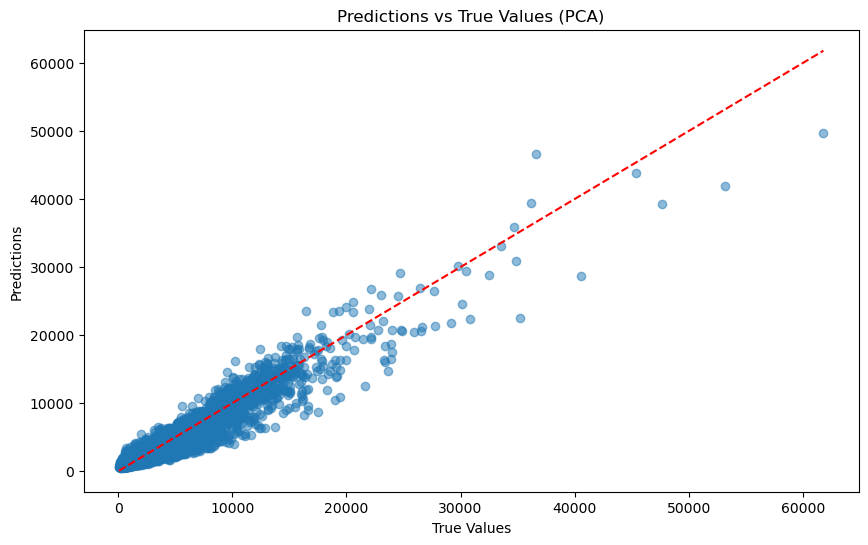

In [7]:
print("="*60)
print("УМЕНЬШЕНИЕ РАЗМЕРНОСТИ (PCA)")
print("="*60)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Стандартизируем признаки
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Применяем PCA
pca = PCA(n_components=0.95)  # оставляем 95% дисперсии
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Исходное количество признаков: {X_train.shape[1]}")
print(f"После PCA: {X_train_pca.shape[1]}")

# Обучаем Random Forest на уменьшенных данных
rf_pca = RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)
rf_pca.fit(X_train_pca, y_train)
y_pred_pca = rf_pca.predict(X_test_pca)

print(f"\nRandom Forest после PCA:")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_pca)):,.2f}")
print(f"  R²: {r2_score(y_test, y_pred_pca):.4f}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_pca, alpha=0.5)
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Predictions vs True Values (PCA)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [8]:
from sklearn.ensemble import VotingRegressor, StackingRegressor

print("="*60)
print("АНСАМБЛИ МОДЕЛЕЙ")
print("="*60)

# Voting Regressor
voting = VotingRegressor([
    ('rf', RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)),
    ('xgb', xgb.XGBRegressor(n_estimators=100, random_state=RANDOM_SEED, verbosity=0)),
    ('lgb', lgb.LGBMRegressor(n_estimators=100, random_state=RANDOM_SEED, verbose=-1))
])

voting.fit(X_train, y_train)
y_pred_voting = voting.predict(X_test)

print(f"\nVoting Regressor:")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_voting)):,.2f}")
print(f"  MAE: ${mean_absolute_error(y_test, y_pred_voting):,.2f}")
print(f"  R²: {r2_score(y_test, y_pred_voting):.4f}")

# Stacking Regressor
stacking = StackingRegressor([
    ('rf', RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED)),
    ('xgb', xgb.XGBRegressor(n_estimators=100, random_state=RANDOM_SEED, verbosity=0))
], final_estimator=LinearRegression())

stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)

print(f"\nStacking Regressor:")
print(f"  RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_stacking)):,.2f}")
print(f"  MAE: ${mean_absolute_error(y_test, y_pred_stacking):,.2f}")
print(f"  R²: {r2_score(y_test, y_pred_stacking):.4f}")

АНСАМБЛИ МОДЕЛЕЙ

Voting Regressor:
  RMSE: $389.20
  MAE: $32.72
  R²: 0.9846

Stacking Regressor:
  RMSE: $195.71
  MAE: $12.03
  R²: 0.9961


In [9]:
print("="*60)
print("ИТОГОВАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ")
print("="*60)

final_results = pd.DataFrame([
    {'Model': 'Linear Regression (Baseline)', 'RMSE': '$626.55', 'MAE': '$322.13', 'R²': '0.9601'},
    {'Model': 'Ridge', 'RMSE': results[0]['RMSE'], 'MAE': results[0]['MAE'], 'R²': results[0]['R²']},
    {'Model': 'Lasso', 'RMSE': results[1]['RMSE'], 'MAE': results[1]['MAE'], 'R²': results[1]['R²']},
    {'Model': 'Random Forest', 'RMSE': results[2]['RMSE'], 'MAE': results[2]['MAE'], 'R²': results[2]['R²']},
    {'Model': 'XGBoost', 'RMSE': results[3]['RMSE'], 'MAE': results[3]['MAE'], 'R²': results[3]['R²']},
    {'Model': 'LightGBM', 'RMSE': results[4]['RMSE'], 'MAE': results[4]['MAE'], 'R²': results[4]['R²']},
    {'Model': 'Voting Regressor', 'RMSE': f'${np.sqrt(mean_squared_error(y_test, y_pred_voting)):,.2f}', 
     'MAE': f'${mean_absolute_error(y_test, y_pred_voting):,.2f}', 
     'R²': f'{r2_score(y_test, y_pred_voting):.4f}'},
    {'Model': 'Stacking Regressor', 'RMSE': f'${np.sqrt(mean_squared_error(y_test, y_pred_stacking)):,.2f}', 
     'MAE': f'${mean_absolute_error(y_test, y_pred_stacking):,.2f}', 
     'R²': f'{r2_score(y_test, y_pred_stacking):.4f}'},
    {'Model': 'Random Forest (Optimized)', 'RMSE': f'${np.sqrt(mean_squared_error(y_test, y_pred_best)):,.2f}', 
     'MAE': f'${mean_absolute_error(y_test, y_pred_best):,.2f}', 
     'R²': f'{r2_score(y_test, y_pred_best):.4f}'}
])

print(final_results.to_string(index=False))

# Выбор лучшей модели
best_row = final_results.loc[final_results['R²'].astype(float).idxmax()]
print(f"\n" + "="*60)
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_row['Model']}")
print(f"R² = {best_row['R²']}")
print("="*60)

ИТОГОВАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ
                       Model    RMSE     MAE     R²
Linear Regression (Baseline) $626.55 $322.13 0.9601
                       Ridge $626.55 $322.08 0.9601
                       Lasso $626.69 $320.66 0.9601
               Random Forest $194.70  $11.53 0.9961
                     XGBoost $564.42  $57.81 0.9676
                    LightGBM $533.39  $50.61 0.9711
            Voting Regressor $389.20  $32.72 0.9846
          Stacking Regressor $195.71  $12.03 0.9961
   Random Forest (Optimized) $196.56  $11.67 0.9961

ЛУЧШАЯ МОДЕЛЬ: Random Forest
R² = 0.9961


In [10]:
import joblib

# Сохраняем лучшую модель
joblib.dump(best_rf, 'best_model.pkl')
print("Модель сохранена как 'best_model.pkl'")

# Дополнительно сохраним Random Forest из списка моделей
rf_model = models['Random Forest']
joblib.dump(rf_model, 'random_forest_model.pkl')
print("Random Forest модель сохранена")

Модель сохранена как 'best_model.pkl'
Random Forest модель сохранена
